In [1]:
# !pip install matplotlib
# !pip install seaborn

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.optim.lr_scheduler import CosineAnnealingLR

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, f1_score

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


In [7]:
# 대회 데이터 정보 읽기
train_csv = pd.read_csv('train.csv')
meta_csv = pd.read_csv('meta.csv')

print("Train CSV:")
print(train_csv.head())
print(f"\n총 이미지: {len(train_csv)}")

print("\nMeta CSV:")
print(meta_csv)
print(f"총 클래스: {len(meta_csv)}")

# 2. 클래스별 이미지 개수 확인
print("\n클래스별 이미지 분포:")
print(train_csv['target'].value_counts().sort_index())


Train CSV:
                     ID  target
0  002f99746285dfdd.jpg      16
1  008ccd231e1fea5d.jpg      10
2  008f5911bfda7695.jpg      10
3  009235e4c9c07af5.jpg       4
4  00b2f44967580c74.jpg      16

총 이미지: 1570

Meta CSV:
    target                                         class_name
0        0                                     account_number
1        1  application_for_payment_of_pregnancy_medical_e...
2        2                                      car_dashboard
3        3            confirmation_of_admission_and_discharge
4        4                                          diagnosis
5        5                                     driver_lisence
6        6                              medical_bill_receipts
7        7                     medical_outpatient_certificate
8        8                                   national_id_card
9        9                                           passport
10      10                               payment_confirmation
11      11                   

In [8]:
# 2. Semantic Group 정의 (영어 클래스명 기준)
# Semantic Grouping 먼저 하기로 판단 -극단적 변형에서 그룹 분류가 우선, 세부 분류는 그룹 내에서만 하는 것이 좋다고 판단

class_group_mapping = {
    'account_number': 'other',
    'application_for_payment_of_pregnancy_medical_expenses': 'medical',
    'car_dashboard': 'vehicle',
    'confirmation_of_admission_and_discharge': 'medical',
    'diagnosis': 'medical',
    'driver_lisence': 'identity',
    'medical_bill_receipts': 'medical',
    'medical_outpatient_certificate': 'medical',
    'national_id_card': 'identity',
    'passport': 'identity',
    'payment_confirmation': 'medical',
    'pharmaceutical_receipt': 'medical',
    'prescription': 'medical',
    'resume': 'document',
    'statement_of_opinion': 'document',
    'vehicle_registration_certificate': 'vehicle',
    'vehicle_registration_plate': 'vehicle',
}

# 3. Group 인덱스 매핑 (변수명 명확하게 분리!)
group_to_idx_dict = {'medical': 0, 'identity': 1, 'vehicle': 2, 'document': 3, 'other': 4}

# Target → Group 매핑 생성
target_group = {}
target_group_idx = {}

print("\n=== 클래스-그룹 매핑 결과 ===")
for idx, row in meta_csv.iterrows():
    target = row['target']
    class_name = row['class_name']
    
    # 정확한 매칭
    group = class_group_mapping.get(class_name, 'other')
    group_idx_val = group_to_idx_dict[group]  # 변수명 다르게!
    
    target_group[target] = group
    target_group_idx[target] = group_idx_val
    
    print(f"Target {target:2d}: {class_name:50s} → {group:8s} (group_idx: {group_idx_val})")

# 4. Train CSV에 그룹 정보 추가
train_csv['group'] = train_csv['target'].map(target_group)
train_csv['group_idx'] = train_csv['target'].map(target_group_idx)

print("\n=== 최종 Train 데이터 ===")
print(train_csv.head(10))

print("\n=== 그룹별 클래스 분포 ===")
print(train_csv.groupby(['group', 'target']).size())

print("\n=== 그룹별 이미지 개수 ===")
print(train_csv.groupby('group').size())



=== 클래스-그룹 매핑 결과 ===
Target  0: account_number                                     → other    (group_idx: 4)
Target  1: application_for_payment_of_pregnancy_medical_expenses → medical  (group_idx: 0)
Target  2: car_dashboard                                      → vehicle  (group_idx: 2)
Target  3: confirmation_of_admission_and_discharge            → medical  (group_idx: 0)
Target  4: diagnosis                                          → medical  (group_idx: 0)
Target  5: driver_lisence                                     → identity (group_idx: 1)
Target  6: medical_bill_receipts                              → medical  (group_idx: 0)
Target  7: medical_outpatient_certificate                     → medical  (group_idx: 0)
Target  8: national_id_card                                   → identity (group_idx: 1)
Target  9: passport                                           → identity (group_idx: 1)
Target 10: payment_confirmation                               → medical  (group_idx: 0)
Target 

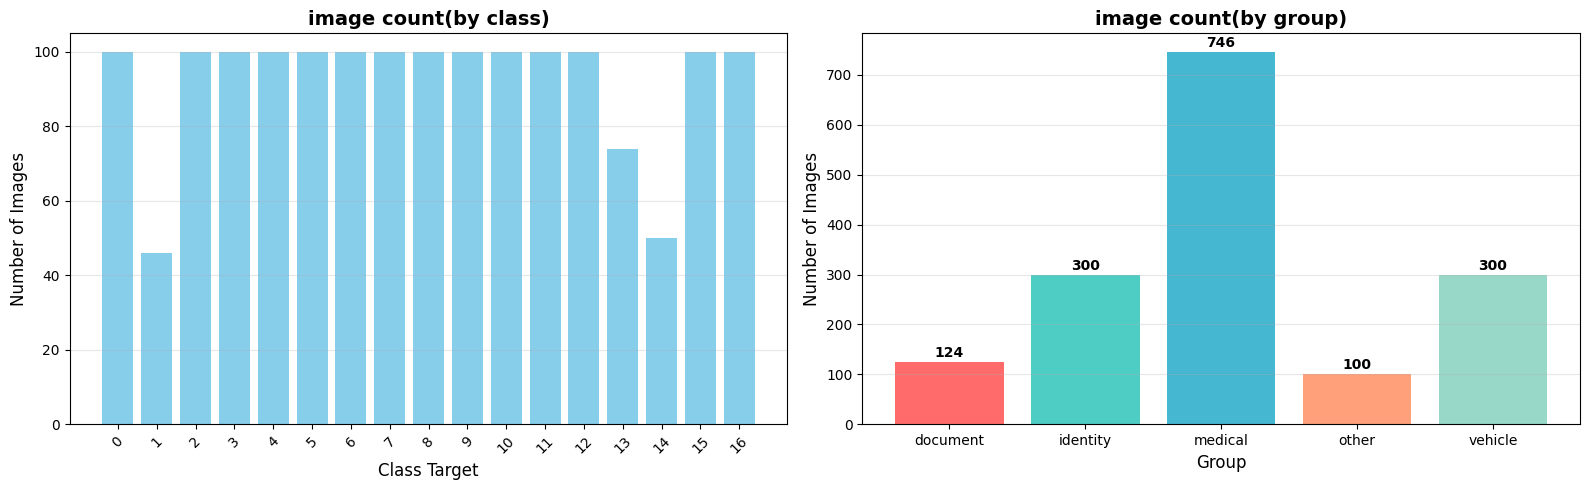

클래스별 분포: {0: 100, 1: 46, 2: 100, 3: 100, 4: 100, 5: 100, 6: 100, 7: 100, 8: 100, 9: 100, 10: 100, 11: 100, 12: 100, 13: 74, 14: 50, 15: 100, 16: 100}
그룹별 분포:
group
document    124
identity    300
medical     746
other       100
vehicle     300
dtype: int64


In [85]:
# EDA

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 왼쪽: 모든 클래스
class_counts = train_csv['target'].value_counts().sort_index()
axes[0].bar(class_counts.index, class_counts.values, color='skyblue')
axes[0].set_xlabel('Class Target', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('image count(by class)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[0].set_xticks(range(0, 17, 1))
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: 그룹별
group_counts = train_csv.groupby('group').size()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
axes[1].bar(group_counts.index, group_counts.values, color=colors)
axes[1].set_xlabel('Group', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('image count(by group)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# 값 표시
for i, v in enumerate(group_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"클래스별 분포: {dict(class_counts)}")
print(f"그룹별 분포:\n{group_counts}")


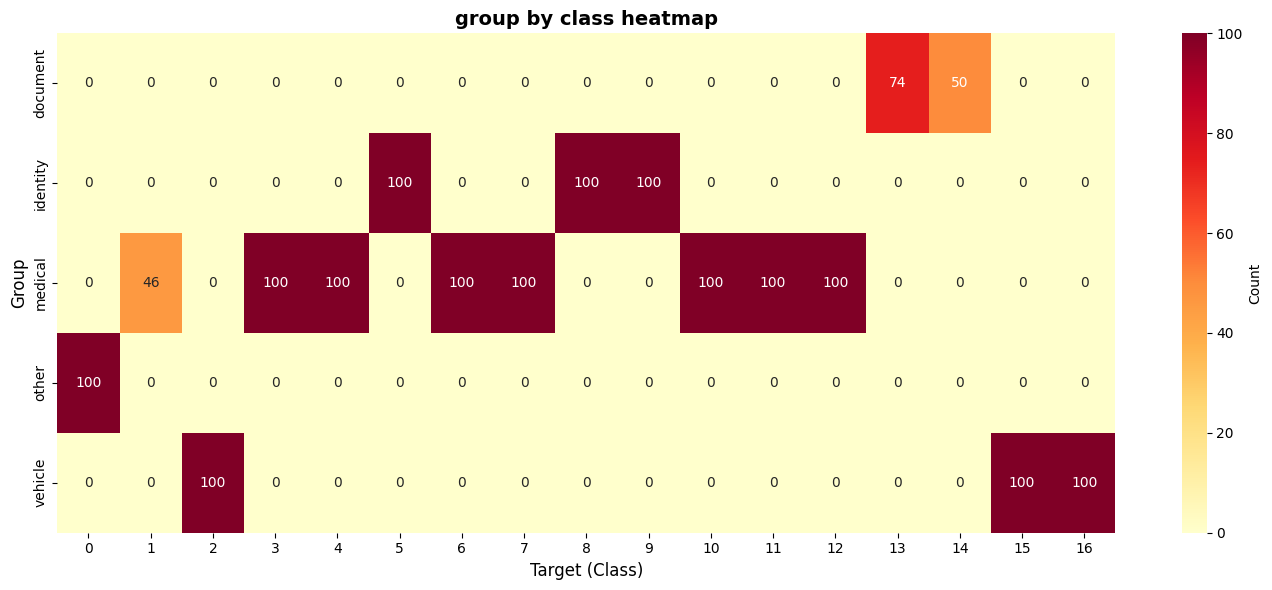

그룹별 클래스 구성 시각화 완료


In [9]:
# 그룹별 클래스 구성 (의미없음)

group_class_matrix = pd.crosstab(train_csv['group'], train_csv['target'])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(group_class_matrix, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_title('group by class heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Target (Class)', fontsize=12)
ax.set_ylabel('Group', fontsize=12)

plt.tight_layout()
plt.savefig('02_group_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("그룹별 클래스 구성 시각화 완료")

In [ ]:
# 그냥 17개를 구분하려고 시도하면 극단적 변형에서는 구분 불가능
# 회전된 상태에서는 분류가 어렵기 때문에 Hierarchical 모델 (2단계)로 나누기로 함
# 1단계: 그룹 분류 어떤 클래스인지?
# 2단계: 그룹 내 세부 분류 n개 중 어느 것?
# random state 재현 가능성

In [41]:
# Train/Validation Split
# 검증 데이터 비율 20% -> 데이터 수가 수만개가 아닌 수천개일 경우, 신뢰도 확보를 위한 20%
# stratify 각 클래스 비율을 유지해서 분할 
# random state 재현 가능성

# train_data, val_data = train_test_split(
#     train_csv,
#     test_size=0.2,
#     stratify=train_csv['group_idx'],
#     random_state=42
# )

# train_data = train_data.reset_index(drop=True)
# val_data = val_data.reset_index(drop=True)

# print(f"\n=== Train/Val Split ===")
# print(f"Train: {len(train_data)}, Val: {len(val_data)}")


=== Train/Val Split ===
Train: 1256, Val: 314


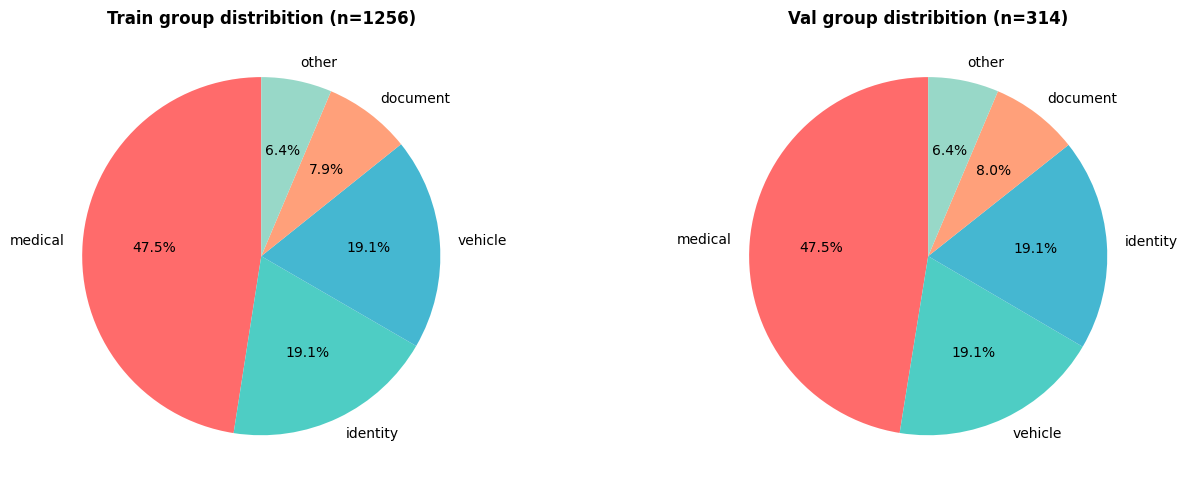

✓ Train 분포:
group
medical     597
identity    240
vehicle     240
document     99
other        80
Name: count, dtype: int64
✓ Val 분포:
group
medical     149
vehicle      60
identity     60
document     25
other        20
Name: count, dtype: int64


In [43]:
# Train/Val 그룹 분포 비교

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_group_counts = train_data['group'].value_counts()
val_group_counts = val_data['group'].value_counts()

# Train 분포
axes[0].pie(train_group_counts.values, labels=train_group_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title(f'Train group distribition (n={len(train_data)})', fontsize=12, fontweight='bold')

# Val 분포
axes[1].pie(val_group_counts.values, labels=val_group_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title(f'Val group distribition (n={len(val_data)})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('03_train_val_split.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Train 분포:\n{train_group_counts}")
print(f"✓ Val 분포:\n{val_group_counts}")


In [10]:
# Augmentation 

# Train 데이터용 (극단적 증강)
train_transform = A.Compose([
    A.Rotate(limit=180, p=0.8),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomCrop(height=224, width=224, p=0.6),
    A.GaussNoise(var_limit=(20, 100), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, p=0.3),
    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
    ], p=0.2),
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], 
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Val 데이터용 (증강 없음, 정규화만)
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], 
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Test 데이터용
test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], 
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [17]:
# Dataset 클래스 정의

class DocumentDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_name = row['ID']
        img_path = os.path.join(self.image_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))

        image = np.array(image)
        
        if self.transform:
            image = self.transform(image=image)['image']
        
        target = torch.tensor(row['target'], dtype=torch.long)
        group_idx = torch.tensor(row['group_idx'], dtype=torch.long)
        
        return {
            'image': image,
            'target': target,
            'group_idx': group_idx,
        }


In [12]:
# ============================================================================
# Step 3: DataLoader 생성
# ============================================================================

print("="*60)
print("Step 3: DataLoader 생성")
print("="*60)

BATCH_SIZE = 32

# Dataset 생성
train_dataset = DocumentDataset(train_data, 'train/', transform=train_transform)
val_dataset = DocumentDataset(val_data, 'train/', transform=val_transform)

# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✓ Train DataLoader: {len(train_loader)} batches")
print(f"✓ Val DataLoader: {len(val_loader)} batches")
print(f"✓ Batch Size: {BATCH_SIZE}")

# 샘플 배치 확인
batch = next(iter(train_loader))
print(f"\n샘플 배치 정보:")
print(f"  - Image shape: {batch['image'].shape}")
print(f"  - Target shape: {batch['target'].shape}")
print(f"  - Group shape: {batch['group_idx'].shape}")


Step 3: DataLoader 생성


NameError: name 'train_data' is not defined

1️⃣ Train DataLoader: 40 batches산:
  Train 데이터: 1,256장
  Batch Size: 3
  2장
  
  배치 개수 = 1,256 ÷ 32 = 39.25 → 40 batches
  (마지막 배치는 24장)

의미:
  - 학습할 때, 32장씩 40번 데이터를 넘김
  - 1 epoch = 40 iterations
2️⃣ Val DataLoaderhes
text
계산:
  Val 데이터: 314장
  Batch Size: 32장
  
  배치 개수 = 314 ÷ 32 = 9.8125 → 10 batches
  (마지막 배치는 18장)

의미:
  - 검증할 때, 32장씩 10번 데이터를 넘김
  - 
1 epoch = 10 e([32][3][224][224])
text
[32, 3, 224, 224]
 ↓  ↓    ↓    ↓
 |  |    |    └─ Height (높이)
 |  |    └─────── Width (너비)
 |  └──────────── Channels (RGB = 3)
 └────미지는 RGB 3채널
  - 각 이미지 크기는 224×224 픽셀

In [90]:
import torch
print(torch.cuda.is_available())  # True 또는 False
print(torch.cuda.get_device_name(0)) 

True
NVIDIA GeForce RTX 3090


In [91]:
# ============================================================================
# Step 4: Hierarchical Model 정의
# ============================================================================

print("="*60)
print("Step 4: Hierarchical Model 정의")
print("="*60)

class HierarchicalDocumentClassifier(nn.Module):
    def __init__(self, num_groups=5, num_classes=17):
        super().__init__()
        
        # Backbone (EfficientNet-B3)
        self.backbone = timm.create_model(
            'efficientnet_b3',
            pretrained=True,
            num_classes=0  # FC layer 제거
        )
        self.feature_dim = 1536
        
        # 1단계: 그룹 분류 헤드
        self.group_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_groups)
        )
        
        # 2단계: 세부 분류 헤드 (각 그룹별)
        self.fine_heads = nn.ModuleDict({
            'medical': nn.Linear(self.feature_dim, 8),      # 의료: 8개
            'identity': nn.Linear(self.feature_dim, 3),     # 신분증: 3개
            'vehicle': nn.Linear(self.feature_dim, 3),      # 차량: 3개
            'document': nn.Linear(self.feature_dim, 2),     # 문서: 2개
            'other': nn.Linear(self.feature_dim, 1),        # 기타: 1개
        })
        
        self.group_names = ['medical', 'identity', 'vehicle', 'document', 'other']
    
    def forward(self, x):
        # 공유 backbone에서 특징 추출
        features = self.backbone(x)  # (B, 1536)
        
        # 1단계: 그룹 분류
        group_logits = self.group_head(features)
        
        # 2단계: 세부 분류 (모든 헤드 계산)
        fine_logits_list = []
        for group_name in self.group_names:
            logits = self.fine_heads[group_name](features)
            fine_logits_list.append(logits)
        
        # 전체 17개 클래스에 대한 logits 생성
        fine_logits = torch.cat(fine_logits_list, dim=1)  # (B, 17)
        
        return group_logits, fine_logits

# 모델 생성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HierarchicalDocumentClassifier(num_groups=5, num_classes=17)
model = model.to(device)

# 모델 파라미터 확인
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Device: {device}")
print(f"✓ Total parameters: {total_params:,}")
print(f"✓ Trainable parameters: {trainable_params:,}")

# 모델 아키텍처 확인
print(f"\n✓ Model Architecture:")
print(f"  - Backbone: EfficientNet-B3")
print(f"  - Group Head Output: 5 (medical, identity, vehicle, document, other)")
print(f"  - Fine Heads Output: 17 (total classes)")


Step 4: Hierarchical Model 정의
✓ Device: cuda
✓ Total parameters: 11,511,870
✓ Trainable parameters: 11,511,870

✓ Model Architecture:
  - Backbone: EfficientNet-B3
  - Group Head Output: 5 (medical, identity, vehicle, document, other)
  - Fine Heads Output: 17 (total classes)


In [ ]:
# Step 5: Optimizer & Loss 함수 정의


print("="*60)
print("Step 5: Optimizer & Loss 함수 정의")
print("="*60)

# Optimizer (Adam 사용 - 안정적이고 효율적)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=5e-4
)

# Scheduler (학습률 동적 조절)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,  # 30 epochs
    eta_min=5e-6
)

# Loss 함수 (계층적 손실)
def hierarchical_loss(group_logits, fine_logits, group_labels, fine_labels, alpha=0.3):
    """
    계층적 손실 함수
    alpha: 그룹 분류 손실의 가중치 (0.3 = 30%)
    """
    group_loss = torch.nn.functional.cross_entropy(group_logits, group_labels)
    fine_loss = torch.nn.functional.cross_entropy(fine_logits, fine_labels)
    
    total_loss = alpha * group_loss + (1 - alpha) * fine_loss
    
    return total_loss, group_loss, fine_loss

print(f"✓ Optimizer: AdamW (lr=1e-4)")
print(f"✓ Scheduler: CosineAnnealingLR")
print(f"✓ Loss Function: Hierarchical Loss (alpha=0.3)")

# ============================================================================
# Step 6: 학습 함수
# ============================================================================

print("\n" + "="*60)
print("Step 6: 학습 함수 정의")
print("="*60)

def train_one_epoch(loader, model, optimizer, device, alpha=0.3):
    """
    1 epoch 학습
    """
    model.train()
    total_loss = 0
    group_preds, fine_preds = [], []
    group_targets, fine_targets = [], []
    
    pbar = tqdm(loader, desc="Training", ncols=100)
    
    for batch in pbar:
        images = batch['image'].to(device)
        group_labels = batch['group_idx'].to(device)
        fine_labels = batch['target'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        group_logits, fine_logits = model(images)
        
        # Loss 계산
        loss, group_loss, fine_loss = hierarchical_loss(
            group_logits, fine_logits, group_labels, fine_labels, alpha=alpha
        )
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # 통계 수집
        total_loss += loss.item()
        group_preds.extend(torch.argmax(group_logits, dim=1).cpu().detach().numpy())
        fine_preds.extend(torch.argmax(fine_logits, dim=1).cpu().detach().numpy())
        group_targets.extend(group_labels.cpu().numpy())
        fine_targets.extend(fine_labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # 평가 지표 계산
    from sklearn.metrics import accuracy_score, f1_score
    
    group_acc = accuracy_score(group_targets, group_preds)
    fine_acc = accuracy_score(fine_targets, fine_preds)
    fine_f1 = f1_score(fine_targets, fine_preds, average='macro', zero_division=0)
    
    return {
        'loss': total_loss / len(loader),
        'group_acc': group_acc,
        'fine_acc': fine_acc,
        'fine_f1': fine_f1,
    }

print("✓ train_one_epoch 함수 정의 완료")

# ============================================================================
# Step 7: 평가 함수
# ============================================================================

def evaluate(loader, model, device):
    """
    모델 평가 (Val/Test)
    """
    model.eval()
    group_preds, fine_preds = [], []
    group_targets, fine_targets = [], []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating", ncols=100)
        
        for batch in pbar:
            images = batch['image'].to(device)
            group_labels = batch['group_idx'].to(device)
            fine_labels = batch['target'].to(device)
            
            group_logits, fine_logits = model(images)
            
            group_preds.extend(torch.argmax(group_logits, dim=1).cpu().numpy())
            fine_preds.extend(torch.argmax(fine_logits, dim=1).cpu().numpy())
            group_targets.extend(group_labels.cpu().numpy())
            fine_targets.extend(fine_labels.cpu().numpy())
    
    from sklearn.metrics import accuracy_score, f1_score
    
    group_acc = accuracy_score(group_targets, group_preds)
    fine_acc = accuracy_score(fine_targets, fine_preds)
    fine_f1 = f1_score(fine_targets, fine_preds, average='macro', zero_division=0)
    
    return {
        'group_acc': group_acc,
        'fine_acc': fine_acc,
        'fine_f1': fine_f1,
    }

print("✓ evaluate 함수 정의 완료")


In [ ]:
# ============================================================================
# Step 8: 전체 학습 루프 (30 EPOCHS)
# ============================================================================

print("\n" + "="*60)
print("Step 8: 전체 학습 루프 시작")
print("="*60)

NUM_EPOCHS = 30
ALPHA = 0.3  # 그룹 손실 가중치
best_f1 = 0
best_model_path = 'best_hierarchical_model.pth'

# 학습 히스토리 저장
history = {
    'train_loss': [],
    'train_group_acc': [],
    'train_fine_acc': [],
    'train_fine_f1': [],
    'val_group_acc': [],
    'val_fine_acc': [],
    'val_fine_f1': [],
}

print(f"\n🚀 학습 설정:")
print(f"  - 총 Epochs: {NUM_EPOCHS}")
print(f"  - Device: {device}")
print(f"  - Optimizer: AdamW (lr=1e-4)")
print(f"  - Alpha (Group Loss Weight): {ALPHA}")
print(f"  - Total Training Iterations: {NUM_EPOCHS * len(train_loader)}")

print(f"\n{'='*60}")
print(f"학습 시작!")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    print(f"\n[Epoch {epoch+1}/{NUM_EPOCHS}]")
    print("-" * 60)
    
    # ===== TRAIN =====
    train_metrics = train_one_epoch(train_loader, model, optimizer, device, alpha=ALPHA)
    
    # 히스토리 저장
    history['train_loss'].append(train_metrics['loss'])
    history['train_group_acc'].append(train_metrics['group_acc'])
    history['train_fine_acc'].append(train_metrics['fine_acc'])
    history['train_fine_f1'].append(train_metrics['fine_f1'])
    
    print(f"[TRAIN] Loss: {train_metrics['loss']:.4f}")
    print(f"        Group Acc: {train_metrics['group_acc']:.4f} | Fine Acc: {train_metrics['fine_acc']:.4f} | Fine F1: {train_metrics['fine_f1']:.4f}")
    
    # ===== VAL =====
    val_metrics = evaluate(val_loader, model, device)
    
    # 히스토리 저장
    history['val_group_acc'].append(val_metrics['group_acc'])
    history['val_fine_acc'].append(val_metrics['fine_acc'])
    history['val_fine_f1'].append(val_metrics['fine_f1'])
    
    print(f"[VAL]   Group Acc: {val_metrics['group_acc']:.4f} | Fine Acc: {val_metrics['fine_acc']:.4f} | Fine F1: {val_metrics['fine_f1']:.4f}")
    
    # ===== 최고 모델 저장 =====
    if val_metrics['fine_f1'] > best_f1:
        best_f1 = val_metrics['fine_f1']
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ 최고 모델 저장! (F1: {best_f1:.4f})")
    
    # ===== Scheduler 스텝 =====
    scheduler.step()

print(f"\n{'='*60}")
print(f"✅ 학습 완료!")
print(f"{'='*60}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Best Model Path: {best_model_path}\n")



Step 8: 전체 학습 루프 시작

🚀 학습 설정:
  - 총 Epochs: 30
  - Device: cuda
  - Optimizer: AdamW (lr=1e-4)
  - Alpha (Group Loss Weight): 0.3
  - Total Training Iterations: 1200

학습 시작!


[Epoch 1/30]
------------------------------------------------------------


Training: 100%|████████████████████████████████████████| 40/40 [00:13<00:00,  2.91it/s, loss=2.4423]


[TRAIN] Loss: 2.4670
        Group Acc: 0.2396 | Fine Acc: 0.0549 | Fine F1: 0.0507


Evaluating: 100%|███████████████████████████████████████████████████| 10/10 [00:01<00:00,  7.11it/s]


[VAL]   Group Acc: 0.2930 | Fine Acc: 0.0478 | Fine F1: 0.0392
✅ 최고 모델 저장! (F1: 0.0392)

[Epoch 2/30]
------------------------------------------------------------


...

Evaluating: 100%|███████████████████████████████████████████████████| 10/10 [00:01<00:00,  7.04it/s]


[VAL]   Group Acc: 0.2994 | Fine Acc: 0.0446 | Fine F1: 0.0418

[Epoch 19/30]
------------------------------------------------------------


Training: 100%|████████████████████████████████████████| 40/40 [00:13<00:00,  3.01it/s, loss=2.4612]


[TRAIN] Loss: 2.4710
        Group Acc: 0.2707 | Fine Acc: 0.0438 | Fine F1: 0.0404


Evaluating:  50%|██████████████████████████                          | 5/10 [00:00<00:00,  7.29it/s]

In [67]:
class TestDocumentDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # ✅ 수정: DataFrame에서 row 가져오기
        row = self.dataframe.iloc[idx]
        img_name = row['ID']
        img_path = os.path.join(self.image_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {img_path}")
            image = Image.new('RGB', (224, 224))
        
        # PIL Image → numpy array
        image = np.array(image)
        
        # Augmentation 적용
        if self.transform:
            image = self.transform(image=image)['image']
        
        return {
            'image': image,
            'img_name': img_name
        }

print("✓ TestDocumentDataset 클래스 정의 완료\n")



✓ TestDocumentDataset 클래스 정의 완료



In [81]:
# # Step 9: Test 추론 & 제출 파일 생성
# # ============================================================================

# print("\n" + "="*60)
# print("Step 9: Test 추론 & 제출 파일 생성")
# print("="*60)

# # 1. 최고 모델 로드
# print("\n1️⃣  최고 모델 로드")
# model.load_state_dict(torch.load(best_model_path, map_location=device))
# model.eval()
# print(f"✓ 모델 로드 완료: {best_model_path}")

# # 2. Test 데이터셋 생성
# print("\n2️⃣  Test 데이터셋 생성")
# test_files = sorted(os.listdir('test/'))

# # ✅ 수정: DataFrame으로 변환
# test_dataframe = pd.DataFrame({
#     'ID': test_files,
#     'target': 0,        # 더미 값 (사용 안 함)
#     'group_idx': 0      # 더미 값 (사용 안 함)
# })

# # ✅ TestDocumentDataset 사용
# test_dataset = TestDocumentDataset(
#     test_dataframe,
#     'test/',
#     transform=test_transform
# )

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=True
# )

# print(f"✓ Test 데이터: {len(test_dataframe)}장")
# print(f"✓ Test DataLoader: {len(test_loader)} batches")

# # 3. Test 추론
# print("\n3️⃣  Test 추론 시작")
# all_predictions = []
# all_img_names = []

# with torch.no_grad():
#     pbar = tqdm(test_loader, desc="Inference", ncols=100)
    
#     for batch in pbar:
#         images = batch['image'].to(device)
#         img_names = batch['img_name']
        
#         # Forward pass
#         group_logits, fine_logits = model(images)
        
#         # 클래스 예측
#         predictions = torch.argmax(fine_logits, dim=1).cpu().numpy()
        
#         all_predictions.extend(predictions)
#         all_img_names.extend(img_names)

# print(f"✓ 추론 완료: {len(all_predictions)}개 이미지")

# # 4. 제출 파일 생성
# print("\n4️⃣  제출 파일 생성")
# submission_df = pd.DataFrame({
#     'ID': all_img_names,
#     'target': all_predictions
# })

# submission_path = 'submission_EN_HC.csv'
# submission_df.to_csv(submission_path, index=False)

# print(f"✓ 제출 파일 저장: {submission_path}")
# print(f"\n제출 파일 샘플:")
# print(submission_df.head(10))
# print(f"\n제출 파일 통계:")
# print(f"  - 총 이미지: {len(submission_df)}")
# print(f"  - 클래스 분포:")
# print(submission_df['target'].value_counts().sort_index())

# print(f"\n{'='*60}")
# print(f"✅ 추론 완료!")
# print(f"{'='*60}")

EfficientNet-B3 + Hierarchical Classificationxt
1. 백본: EfficientNet-B3 (이미지 → 특징)
2. 그룹 헤드: 5개 그룹 분류
3. 세부 헤드: 각 그룹 내 세부 분류 (17개 총합)
4. 손실 함수: 계층적 손실 (그룹 + 세부 모두 고려)
5. 평가 지표: Macro F1 (불균형 데이터 대응)

결과: F1 = 0.9033 🎉

In [70]:
print(submission_df.columns.tolist())

['ID', 'target']


In [ ]:
# K-Fold Cross Validation 설정

print("\n" + "="*60)
print("K-Fold Cross Validation 준비")
print("="*60)

K_FOLDS = 5
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

print(f"✓ K-Fold: {K_FOLDS}-Fold")
print(f"✓ 총 학습 횟수: {K_FOLDS}회")
print(f"✓ 각 Fold별 Train: {int(len(train_csv) * (1 - 1/K_FOLDS))}장")
print(f"✓ 각 Fold별 Val: {int(len(train_csv) / K_FOLDS)}장")

# K-Fold 인덱스 생성
fold_indices = list(kfold.split(train_csv))

print(f"✓ K-Fold 설정 완료!")


In [ ]:
# ============================================================================
# Step 8: K-Fold 학습 루프
# ============================================================================

print("\n" + "="*60)
print("K-Fold 학습 시작")
print("="*60)

fold_results = []
best_overall_f1 = 0
all_fold_models = []

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"\n{'='*60}")
    print(f"[Fold {fold+1}/{K_FOLDS}]")
    print(f"{'='*60}")
    
    # ===== 1. Fold별 데이터 분할 =====
    train_fold = train_csv.iloc[train_idx].reset_index(drop=True)
    val_fold = train_csv.iloc[val_idx].reset_index(drop=True)
    
    print(f"Train: {len(train_fold)}, Val: {len(val_fold)}")
    
    # ===== 2. Dataset & DataLoader =====
    train_fold_dataset = DocumentDataset(train_fold, 'train/', transform=train_transform)
    val_fold_dataset = DocumentDataset(val_fold, 'train/', transform=val_transform)
    
    train_fold_loader = DataLoader(
        train_fold_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )
    
    val_fold_loader = DataLoader(
        val_fold_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )
    
    # ===== 3. 모델 초기화 (매 fold마다 새로 생성) =====
    fold_model = HierarchicalDocumentClassifier(num_groups=5, num_classes=17)
    fold_model = fold_model.to(device)
    
    # ===== 4. Optimizer & Scheduler =====
    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(),
        lr=5e-4,
        weight_decay=5e-4
    )
    
    fold_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        fold_optimizer,
        T_max=30,
        eta_min=5e-6
    )
    
    # ===== 5. Fold별 학습 =====
    best_fold_f1 = 0
    best_fold_model_path = f'best_fold_{fold+1}_model.pth'
    
    for epoch in range(NUM_EPOCHS):
        # Train
        train_metrics = train_one_epoch(
            train_fold_loader, fold_model, fold_optimizer, device, alpha=ALPHA
        )
        
        # Val
        val_metrics = evaluate(val_fold_loader, fold_model, device)
        
        # Print
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[Epoch {epoch+1:2d}] Train Loss: {train_metrics['loss']:.4f} | Val F1: {val_metrics['fine_f1']:.4f}")
        
        # Best Model 저장
        if val_metrics['fine_f1'] > best_fold_f1:
            best_fold_f1 = val_metrics['fine_f1']
            torch.save(fold_model.state_dict(), best_fold_model_path)
        
        fold_scheduler.step()
    
    # ===== 6. Fold 결과 저장 =====
    fold_results.append(best_fold_f1)
    all_fold_models.append(best_fold_model_path)
    
    print(f"\n✅ Fold {fold+1} 완료 | Best F1: {best_fold_f1:.4f}")

# ===== 7. K-Fold 최종 결과 =====
print(f"\n{'='*60}")
print(f"✅ K-Fold 학습 완료!")
print(f"{'='*60}")
print(f"\nFold별 F1 Score:")
for fold, f1 in enumerate(fold_results):
    print(f"  Fold {fold+1}: {f1:.4f}")

print(f"\n📊 통계:")
print(f"  평균 F1: {np.mean(fold_results):.4f}")
print(f"  표준편차: {np.std(fold_results):.4f}")
print(f"  최고 F1: {max(fold_results):.4f}")
print(f"  최저 F1: {min(fold_results):.4f}")

print(f"\n💾 저장된 모델:")
for fold, model_path in enumerate(all_fold_models):
    print(f"  Fold {fold+1}: {model_path}")


In [ ]:
# ============================================================================
# Step 10: Ensemble Inference (모든 Fold 모델 활용)
# ============================================================================

print("\n" + "="*60)
print("Step 10: Ensemble Inference")
print("="*60)

# 1. 모든 Fold 모델 로드
print("\n1️⃣  모든 Fold 모델 로드")
ensemble_models = []

for fold in range(K_FOLDS):
    fold_model = HierarchicalDocumentClassifier(num_groups=5, num_classes=17)
    fold_model_path = f'best_fold_{fold+1}_model.pth'
    fold_model.load_state_dict(torch.load(fold_model_path, map_location=device))
    fold_model = fold_model.to(device)
    fold_model.eval()
    ensemble_models.append(fold_model)
    print(f"  ✓ Fold {fold+1} 모델 로드: {fold_model_path}")

print(f"✓ 총 {K_FOLDS}개 모델 로드 완료")

# 2. Test 데이터셋 생성
print("\n2️⃣  Test 데이터셋 생성")
test_files = sorted(os.listdir('test/'))
test_dataframe = pd.DataFrame({
    'ID': test_files,
    'target': 0,
    'group_idx': 0
})

test_dataset = TestDocumentDataset(test_dataframe, 'test/', transform=test_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✓ Test 데이터: {len(test_dataframe)}장")

# 3. 앙상블 추론
print("\n3️⃣  앙상블 추론 시작")
all_ensemble_logits = []
all_img_names = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Ensemble Inference", ncols=100)
    
    for batch in pbar:
        images = batch['image'].to(device)
        img_names = batch['img_name']
        
        # 모든 Fold 모델의 logits 수집
        batch_logits = []
        
        for fold_idx, fold_model in enumerate(ensemble_models):
            group_logits, fine_logits = fold_model(images)
            batch_logits.append(fine_logits.cpu().numpy())
        
        # Logits 평균 (앙상블)
        ensemble_logit = np.mean(batch_logits, axis=0)  # (B, 17)
        
        all_ensemble_logits.append(ensemble_logit)
        all_img_names.extend(img_names)

print(f"✓ 추론 완료: {len(all_img_names)}개 이미지")

# 4. 앙상블 예측 (평균 logits에서 argmax)
print("\n4️⃣  앙상블 예측 생성")
all_ensemble_logits = np.concatenate(all_ensemble_logits, axis=0)  # (3140, 17)
all_predictions = np.argmax(all_ensemble_logits, axis=1)

print(f"✓ 앙상블 예측 완료")

# 5. 제출 파일 생성
print("\n5️⃣  제출 파일 생성")
submission_df = pd.DataFrame({
    'ID': all_img_names,
    'target': all_predictions
})

submission_path = 'submission_ensemble.csv'
submission_df.to_csv(submission_path, index=False)

print(f"✓ 제출 파일 저장: {submission_path}")
print(f"\n제출 파일 샘플:")
print(submission_df.head(10))
print(f"\n제출 파일 통계:")
print(f"  - 총 이미지: {len(submission_df)}")
print(f"  - 클래스 분포:")
print(submission_df['target'].value_counts().sort_index())

print(f"\n{'='*60}")
print(f"✅ 앙상블 추론 완료!")
print(f"{'='*60}")
print(f"제출 파일: {submission_path}")
